In [1]:
# Imports
import numpy as np
import pandas as pd
import networkx as nx

In [2]:
# load packages for visualization
import matplotlib
import matplotlib.patheffects as path_effects
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator,FormatStrFormatter,MaxNLocator
%matplotlib inline

# Dummy network

In [3]:
# create a graph from a stochastic block model
sizes = [5, 5, 3]
probs = [[0.25, 0.05, 0.02], [0.05, 0.35, 0.07], [0.02, 0.07, 0.40]]
g = nx.stochastic_block_model(sizes, probs, seed=0, directed=True)
len(g)

13

In [4]:
g.edges

OutEdgeView([(1, 6), (1, 9), (3, 7), (5, 10), (6, 5), (6, 9), (6, 11), (8, 1), (8, 5), (8, 9), (9, 5), (9, 7), (11, 10)])

In [ ]:
# make a dateframe with the edges of the graph that has a column for the source, target, and weight of each edge
edges = pd.DataFrame(g.edges(data=True), columns=['bodyId_pre', 'bodyId_post', 'weight'])
edges['weight'] = edges['weight'].apply(lambda x: x['weight'] if 'weight' in x else 1)

,bodyId_pre,bodyId_post,weight
0,1,6,1
1,1,9,1
2,3,7,1
3,5,10,1
4,6,5,1
5,6,9,1
6,6,11,1
7,8,1,1
8,8,5,1
9,8,9,1


In [6]:
# make some edges a different weight to avoid the divide by zero issue in the SA pipeline
edges.loc[edges['bodyId_pre'] == 6, 'weight'] = 2

In [7]:
edges

,bodyId_pre,bodyId_post,weight
0,1,6,1
1,1,9,1
2,3,7,1
3,5,10,1
4,6,5,2
5,6,9,2
6,6,11,2
7,8,1,1
8,8,5,1
9,8,9,1


In [8]:
# find communities in the graph using the greedy modularity algorithm
c = nx.community.greedy_modularity_communities(g)
sorted(c)

[frozenset({5, 6, 10, 11}),
 frozenset({1, 8, 9}),
 frozenset({3, 7}),
 frozenset({0}),
 frozenset({2}),
 frozenset({4}),
 frozenset({12})]

In [ ]:
# make a dataframe listing each node and the community it belongs to
mod_df = pd.DataFrame(columns=['id', 'module'])

# ids go from 0 to 12
for i in range(13):
    mod_df.loc[i, 'id'] = i

# assign the module number to each node based on the community it belongs to
for i, community in enumerate(c):
    for node in community:
        mod_df.loc[node, 'module'] = i+1

mod_df

,id,module
0,0,4
1,1,2
2,2,5
3,3,3
4,4,6
5,5,1
6,6,1
7,7,3
8,8,2
9,9,2


Running simulated annealing...
n=13,  n_iter=50,000,  T_init=1.0000,  T_final=1.00e-03,  cooling=0.99986185
   10.0%  T=0.5012  cost=-11,773  best=-11,773
   20.0%  T=0.2512  cost=-23,232  best=-23,232
   30.0%  T=0.1259  cost=-34,657  best=-34,657
   40.0%  T=0.0631  cost=-45,695  best=-45,695
   50.0%  T=0.0316  cost=-57,074  best=-57,074
   60.0%  T=0.0158  cost=-68,549  best=-68,549
   70.0%  T=0.0079  cost=-79,848  best=-79,848
   80.0%  T=0.0040  cost=-91,427  best=-91,427
   90.0%  T=0.0020  cost=-102,607  best=-102,607
  100.0%  T=0.0010  cost=-114,050  best=-114,050
Elapsed: 1.6s


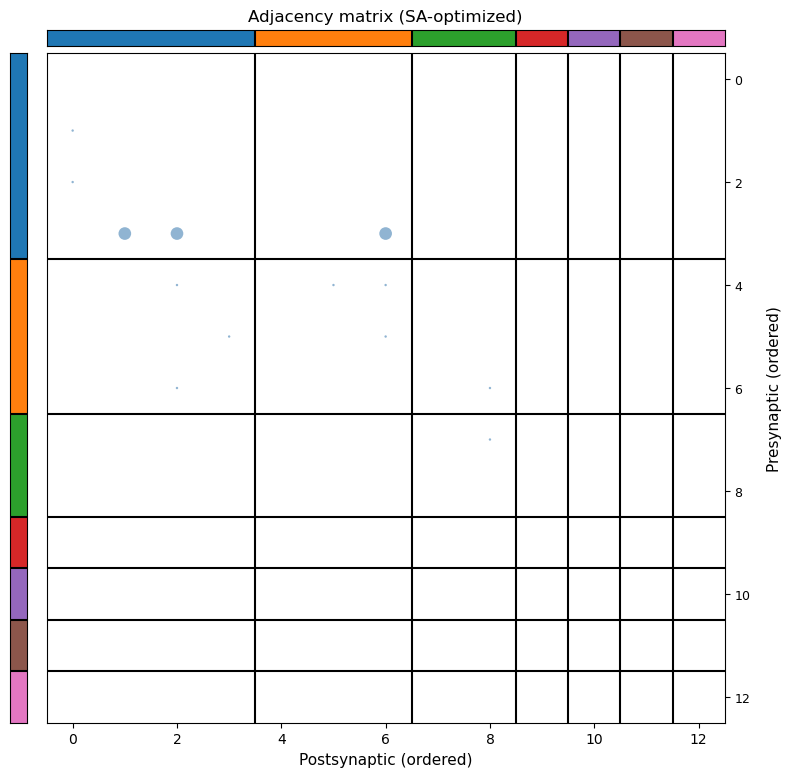

{'A_optimized': array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 2., 2., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 'module_labels': array([1, 1, 1, 1, 2, 2, 2, 3, 3, 4, 5, 6, 7]),
 'module_boundaries': [0, 4, 7, 9, 10, 11, 12, 13],
 'cost_history': [(0, 40.0),
  (5000, -11773.0),
  (10000, 

In [10]:
import simulated_annealing

# run the simulated annealing pipeline
simulated_annealing.run_SA_pipeline(mod_df, edges, plot_style='dot')